# Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd

# Load Dataset

In [2]:
iris = pd.read_csv("iris.csv")
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


# Pre-processing

In [3]:
iris_numerical = iris.drop("species", axis=1)
iris_numerical.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


The "species" column was removed because it contains categorical data.

# Normalising over the standard deviation

In [4]:
from sklearn.preprocessing import StandardScaler
X = iris_numerical.to_numpy()
X = np.nan_to_num(X)
n_iris = StandardScaler().fit_transform(X)
n_iris

array([[-9.00681170e-01,  1.03205722e+00, -1.34127240e+00,
        -1.31297673e+00],
       [-1.14301691e+00, -1.24957601e-01, -1.34127240e+00,
        -1.31297673e+00],
       [-1.38535265e+00,  3.37848329e-01, -1.39813811e+00,
        -1.31297673e+00],
       [-1.50652052e+00,  1.06445364e-01, -1.28440670e+00,
        -1.31297673e+00],
       [-1.02184904e+00,  1.26346019e+00, -1.34127240e+00,
        -1.31297673e+00],
       [-5.37177559e-01,  1.95766909e+00, -1.17067529e+00,
        -1.05003079e+00],
       [-1.50652052e+00,  8.00654259e-01, -1.34127240e+00,
        -1.18150376e+00],
       [-1.02184904e+00,  8.00654259e-01, -1.28440670e+00,
        -1.31297673e+00],
       [-1.74885626e+00, -3.56360566e-01, -1.34127240e+00,
        -1.31297673e+00],
       [-1.14301691e+00,  1.06445364e-01, -1.28440670e+00,
        -1.44444970e+00],
       [-5.37177559e-01,  1.49486315e+00, -1.28440670e+00,
        -1.31297673e+00],
       [-1.26418478e+00,  8.00654259e-01, -1.22754100e+00,
      

A new standardized matrix was created by transforming the features according to their means and standard deviation. This dataset will be used by K-Means to calculate Euclidean distances.

# Modelling

In [5]:
clusterNum = 3
k_means = KMeans(init = "k-means++", n_clusters = clusterNum, n_init = 12)
k_means.fit(n_iris)
labels = k_means.labels_
print(labels)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 0 0 0 2 0 0 0 0 0 0 0 0 2 0 0 0 0 2 0 0 0
 0 2 2 2 0 0 0 0 0 0 0 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 2 2 2 2 2 2 0 0 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


# Insights

In [6]:
iris_numerical["Clus_km"]= labels
iris.head(5)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [7]:
iris_numerical.groupby('Clus_km').mean()

,sepal_length,sepal_width,petal_length,petal_width
Clus_km,,,,
0,5.801887,2.673585,4.369811,1.413208
1,5.006000,3.418000,1.464000,0.244000
2,6.780851,3.095745,5.510638,1.972340


The mean values of the features for each cluster show differences between the groups. Cluster 1 has small petals, Cluster 0 has medium-sized petals, and Cluster 2 has large petals. The K-Means was able to identify meaningful groups based on the flower characteristics.

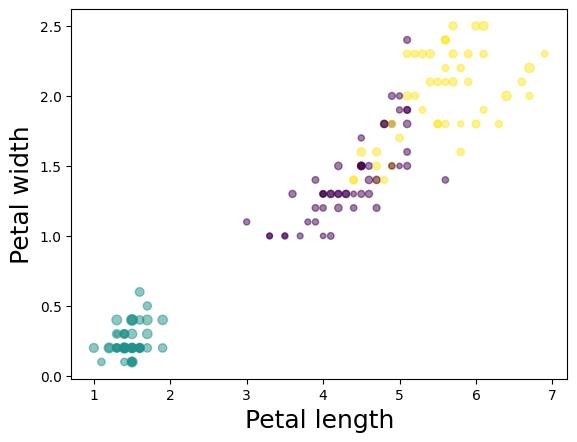

In [8]:
area = np.pi * (X[:, 1])**2
plt.scatter( X[:, 2], X[:, 3], s=area, c=labels.astype(np.float64), alpha = 0.5)
plt.xlabel('Petal length', fontsize =18)
plt.ylabel('Petal width', fontsize = 18)
plt.show()

The scatter plot shows that the three clusters are clearly distinguishable. The yellow and the purple groups are relatively closer to each other but they still form separate regions. The green group is well separated from the others.

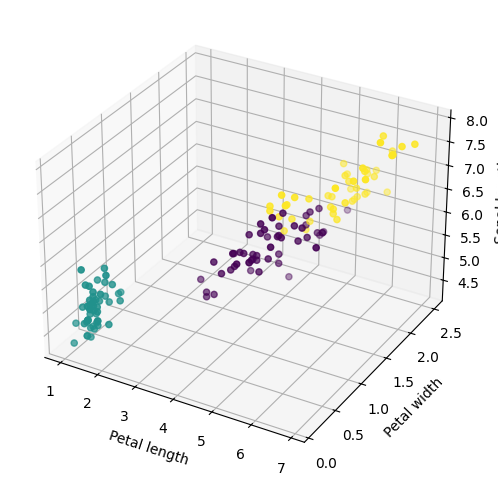

In [9]:
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure( figsize=(8,6))
ax = fig.add_subplot(111, projection = '3d')
ax.set_xlabel('Petal length')
ax.set_ylabel('Petal width')
ax.set_zlabel('Sepal length')
ax.scatter(
    X[:, 2],
    X[:, 3],
    X[:, 0],
    c=labels.astype(np.float64)
)
plt.show()

The 3D scatter plot confirms the separation observed in the 2D scatter plot.

# Setting values for k

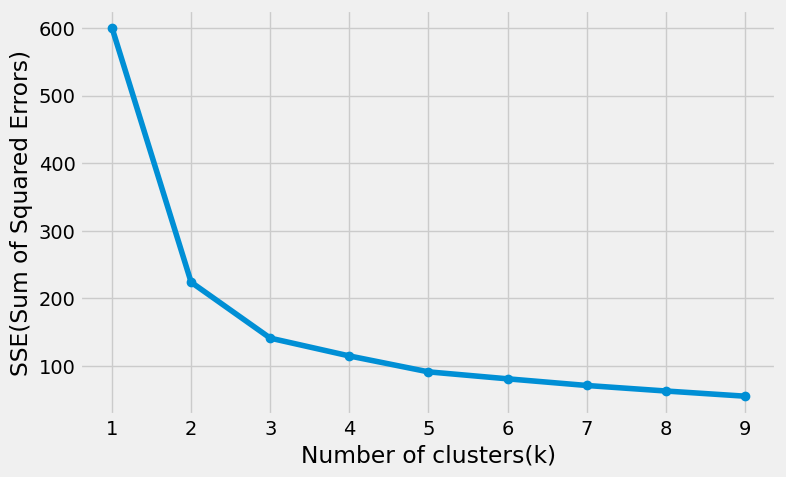

In [14]:
sse = []
for k in range(1,10):
    kmeans = KMeans(n_clusters = k, init= "k-means++", n_init=12, max_iter = 300)
    kmeans.fit(n_iris)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(range(1,10), sse, marker="o")
plt.xlabel("Number of clusters(k)")
plt.ylabel("SSE(Sum of Squared Errors)")
plt.xticks(range(1,10))
plt.show()

The Elbow Method shows a significant decrease in SSE when increasing the number of clusters from 1 to 3. Therefore, 3 appears to be the most appropriate choice.

In [11]:
from sklearn.metrics import silhouette_score, silhouette_samples
silhouette_coefficients= []
for k in range (2, 10):
    kmeans = KMeans(n_clusters=k, init="k-means++", n_init =12, max_iter = 300)
    kmeans.fit(X)
    score = silhouette_score(n_iris, kmeans.labels_)
    silhouette_coefficients.append(score)

silhouette_coefficients


[0.5653839587789065,
 0.44240103164555117,
 0.3645230099550022,
 0.35758404996678034,
 0.2994991413335747,
 0.30048070914461705,
 0.2995864188761023,
 0.2807710298786366]

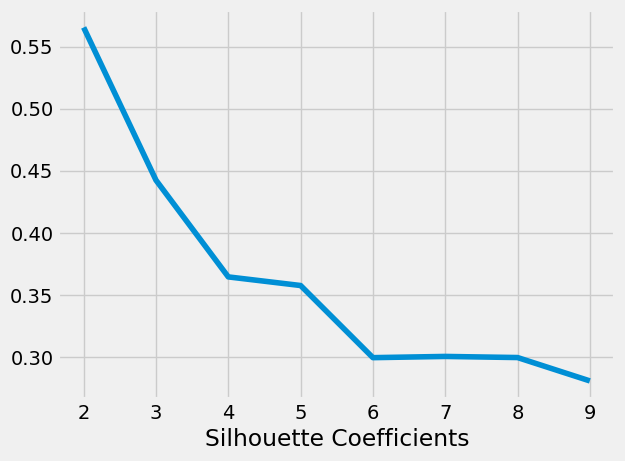

In [12]:
plt.style.use("fivethirtyeight")
plt.plot(range(2, 10), silhouette_coefficients)
plt.xticks(range(2,10))
plt.xlabel("number of clusters")
plt.xlabel("Silhouette Coefficients")
plt.show()

The Silhouette Coefficient was calculated for different clusters. The highest value is obtained with K = 2, meaning that this configuration provides the best separation according to the metrics.
However, K=3 was selected because it was required by the assignment and because the Iris dataset contains three known species.

# Cluster Comparison with Species

In [15]:
iris["Clus_km"] = labels
comparison = pd.crosstab(iris["species"], iris["Clus_km"])
comparison

Clus_km,0,1,2
species,,,
setosa,0,50,0
versicolor,39,0,11
virginica,14,0,36


The comparison between the K-Means clusters and the Iris species shows that Setosa was perfectly identified, with all 50 samples assigned to the same clusters.
    On the other hand, Versicolor and Virginica were not completely separated, as multiple samples from both species were assigned to the same clusters, indicating that these two species share similar characteristics. This makes it difficult for the K-Means to distinguish them. 